<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pr%C3%A1ctica_24_Regresi%C3%B3n_Lineal_M%C3%BAltiple_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Chacón Terrazas Armando
*   Matrícula: 260498

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Tu código aquí
import pandas as pd  # Para trabajar con datos en forma de tablas (DataFrames)
import numpy as np   # Para trabajar con operaciones numéricas

# Cargar el archivo 'advertising.csv' desde Google Drive
archivo = '/content/drive/MyDrive/Unidad03/advertising.csv'
datos = pd.read_csv(archivo)

# Mostrar las primeras filas del DataFrame para ver cómo luce el dataset
print("Primeras filas del dataset:")
print(datos.head())

# Mostrar un resumen estadístico de las variables numéricas
print("\nDescripción estadística de las variables:")
print(datos.describe())

Primeras filas del dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Descripción estadística de las variables:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

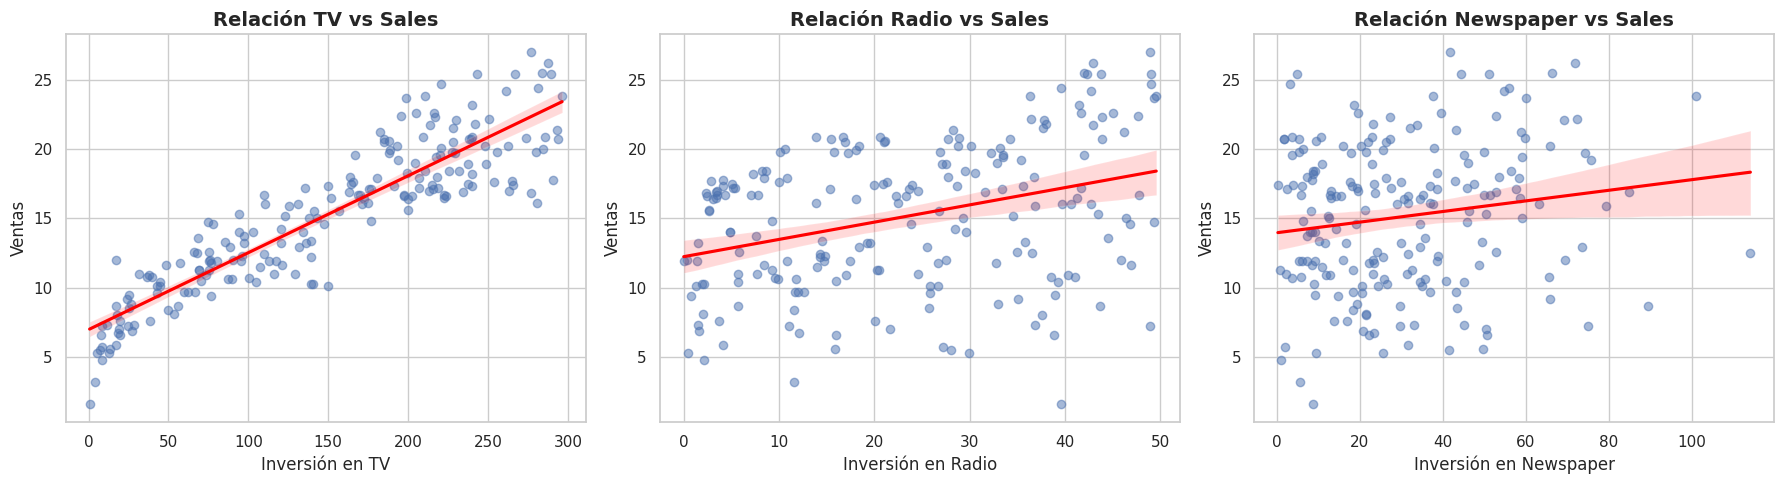

In [3]:
# Importar la biblioteca para visualización de datos
import matplotlib.pyplot as plt  # Para crear gráficos básicos
import seaborn as sns            # Para crear gráficos estadísticos más avanzados

# Configurar el estilo de los gráficos para que se vean mejor
sns.set(style="whitegrid")

# Crear una figura con 3 subgráficos (uno para cada variable independiente)
# figsize controla el tamaño de la figura completa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Relación entre TV y Sales
# regplot crea un gráfico de dispersión con una línea de regresión (tendencia)
sns.regplot(x='TV', y='Sales', data=datos, ax=axes[0],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Relación TV vs Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Inversión en TV', fontsize=12)
axes[0].set_ylabel('Ventas', fontsize=12)

# Gráfico 2: Relación entre Radio y Sales
sns.regplot(x='Radio', y='Sales', data=datos, ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Relación Radio vs Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Inversión en Radio', fontsize=12)
axes[1].set_ylabel('Ventas', fontsize=12)

# Gráfico 3: Relación entre Newspaper y Sales
sns.regplot(x='Newspaper', y='Sales', data=datos, ax=axes[2],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[2].set_title('Relación Newspaper vs Sales', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Inversión en Newspaper', fontsize=12)
axes[2].set_ylabel('Ventas', fontsize=12)

# Ajustar el espaciado entre los gráficos para que no se superpongan
plt.tight_layout()

# Mostrar los gráficos
plt.show()

**2. Interpreta visualmente la relación entre variables.**

El orden de importancia aparente de las variables independientes sobre las ventas es:

TV (relación fuerte)

Radio (relación moderada)

Newspaper (relación débil o inexistente)

### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?

Matriz de Correlación:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000




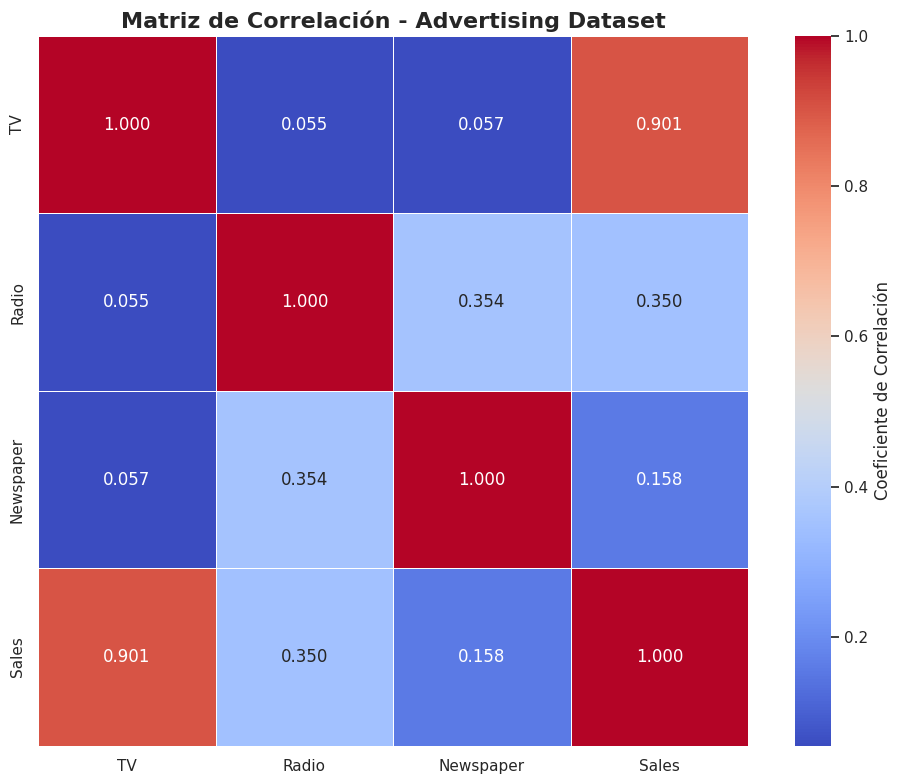

In [4]:
# Correlación y heatmap
# Calcular la matriz de correlación entre todas las variables numéricas
# La correlación mide la relación lineal entre dos variables (valores entre -1 y 1)
matriz_correlacion = datos.corr()

# Mostrar la matriz de correlación en formato de tabla
print("Matriz de Correlación:")
print(matriz_correlacion)
print("\n")

# Crear un heatmap (mapa de calor) para visualizar la matriz de correlación
# El mapa de calor usa colores para representar los valores de correlación
plt.figure(figsize=(10, 8))

# annot=True muestra los valores numéricos en cada celda
# cmap define la paleta de colores (coolwarm va de azul a rojo)
# fmt='.3f' formatea los números a 3 decimales
# square=True hace que las celdas sean cuadradas
# linewidths=0.5 añade líneas entre las celdas
sns.heatmap(matriz_correlacion,
            annot=True,
            cmap='coolwarm',
            fmt='.3f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Correlación'})

# Añadir título al gráfico
plt.title('Matriz de Correlación - Advertising Dataset', fontsize=16, fontweight='bold')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**3.¿Qué variables están más correlacionadas con Sales?**
Observando la última fila/columna del heatmap (Sales), las correlaciones son:

TV: 0.901 - Correlación muy fuerte y positiva
Una correlación de 0.901 indica que prácticamente el 90% de la variabilidad en las ventas se puede explicar linealmente por la inversión en TV

Radio: 0.350 - Correlación moderada y positiva

Existe una relación positiva, pero es considerablemente más débil que TV.

La inversión en Radio tiene un impacto menor en las ventas.

Newspaper: 0.158 - Correlación muy débil y positiva.

Casi no existe relación lineal entre la inversión en periódicos y las ventas
Esta variable tiene muy poco poder predictivo sobre las ventas

**¿Hay correlación alta entre predictores (multicolinealidad)?**
No, no hay correlación alta entre las variables independientes, lo cual es positivo para el modelo de regresión:

TV y Radio: 0.055 - Correlación muy baja (casi inexistente).

TV y Newspaper: 0.057 - Correlación muy baja (casi inexistente).

Radio y Newspaper: 0.354 - Correlación moderada-baja.

Todas las correlaciones entre predictores son menores a 0.4, lo que indica que no existe multicolinealidad significativa. Esto significa que:

Cada variable independiente aporta información única al modelo.

No hay redundancia entre las variables predictoras.

El modelo de regresión múltiple será más estable y confiable.

Los coeficientes estimados serán más precisos.

**Nota:** En general, se considera que hay multicolinealidad problemática cuando la correlación entre predictores supera 0.7 o 0.8.

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?

Variance Inflation Factor (VIF) para cada predictor:
    Variable       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245




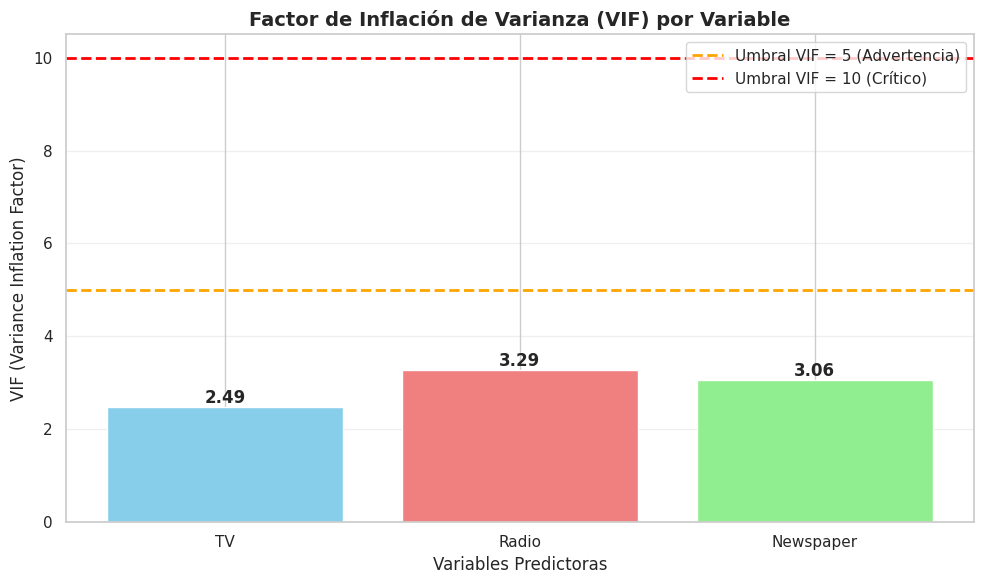

In [5]:
#Multicolinealidad
# Importar la función para calcular el VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar solo las variables independientes (predictores)
# Excluimos 'Sales' porque es la variable dependiente
X = datos[['TV', 'Radio', 'Newspaper']]

# Calcular el VIF para cada variable independiente
# El VIF mide cuánto se infla la varianza de un coeficiente debido a la correlación con otros predictores
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar los resultados del VIF en formato de tabla
print("Variance Inflation Factor (VIF) para cada predictor:")
print(vif_data)
print("\n")

# Crear un gráfico de barras para visualizar los valores de VIF
plt.figure(figsize=(10, 6))

# Crear las barras
bars = plt.bar(vif_data['Variable'], vif_data['VIF'], color=['skyblue', 'lightcoral', 'lightgreen'])

# Añadir los valores numéricos encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Añadir una línea horizontal en VIF = 5 (umbral de advertencia)
plt.axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Umbral VIF = 5 (Advertencia)')

# Añadir una línea horizontal en VIF = 10 (umbral crítico)
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Umbral VIF = 10 (Crítico)')

# Etiquetas y título
plt.xlabel('Variables Predictoras', fontsize=12)
plt.ylabel('VIF (Variance Inflation Factor)', fontsize=12)
plt.title('Factor de Inflación de Varianza (VIF) por Variable', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?**

No, ninguna variable tiene un VIF mayor a 5.

Los valores obtenidos son:

TV: 2.49

Radio: 3.29

Newspaper: 3.06

Todas las variables están muy por debajo de los umbrales críticos:

Umbral de advertencia (VIF = 5): Ninguna variable lo supera.

Umbral crítico (VIF = 10): Ninguna variable lo supera.

**¿Qué implicaciones tiene esto para el modelo?**

No hay multicolinealidad problemática.

Los valores de VIF menores a 5 indican que no existe correlación alta entre las variables predictoras.

Cada variable aporta información única e independiente al modelo.

Coeficientes estables y confiables.

Los coeficientes de regresión estimados serán precisos y no estarán inflados.

Las estimaciones de los parámetros tendrán errores estándar bajos.

Los intervalos de confianza serán más estrechos y confiables.

Modelo robusto.

El modelo será más estable ante pequeños cambios en los datos.

No es necesario eliminar ninguna variable por problemas de multicolinealidad.

Todas las variables pueden permanecer en el modelo.

El dataset de advertising presenta condiciones óptimas para construir un modelo de regresión lineal múltiple, ya que no hay evidencia de multicolinealidad.

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [7]:
#Entrenamiento del Modelo (Todas las Variables Independientes)
# Importar las bibliotecas
from sklearn.linear_model import LinearRegression

# Definir las variables independientes (X) y la variable dependiente (y)
# X contiene todas las variables predictoras
X = datos[['TV', 'Radio', 'Newspaper']]

# y contiene la variable que queremos predecir
y = datos['Sales']

# Crear el modelo de regresión lineal múltiple
modelo = LinearRegression()

# Entrenar el modelo con todos los datos
# El modelo aprende la relación entre X (predictores) y y (ventas)
modelo.fit(X, y)

# Obtener el intercepto (término independiente) del modelo
intercepto = modelo.intercept_

# Obtener los coeficientes de cada variable independiente
coeficientes = modelo.coef_

# Mostrar los resultados del modelo
print("="*60)
print("MODELO DE REGRESIÓN LINEAL MÚLTIPLE")
print("="*60)
print(f"\nIntercepto (β0): {intercepto:.4f}")
print("\nCoeficientes de las variables independientes:")
print("-"*60)

# Mostrar cada coeficiente con su respectiva variable
for variable, coef in zip(X.columns, coeficientes):
    print(f"  {variable:12s} (β): {coef:.4f}")

print("\n" + "="*60)
print("ECUACIÓN DEL MODELO:")
print("="*60)
print(f"Sales = {intercepto:.4f} + {coeficientes[0]:.4f}*TV + {coeficientes[1]:.4f}*Radio + {coeficientes[2]:.4f}*Newspaper")
print("="*60)

MODELO DE REGRESIÓN LINEAL MÚLTIPLE

Intercepto (β0): 4.6251

Coeficientes de las variables independientes:
------------------------------------------------------------
  TV           (β): 0.0544
  Radio        (β): 0.1070
  Newspaper    (β): 0.0003

ECUACIÓN DEL MODELO:
Sales = 4.6251 + 0.0544*TV + 0.1070*Radio + 0.0003*Newspaper


**Interpreta cada uno:¿Qué significa cada uno de los coeficientes  en términos de ventas?**

1. Intercepto (β₀) = 4.6251

Representa las ventas esperadas cuando todas las variables independientes son cero (es decir, cuando no hay inversión en TV, Radio ni Newspaper)

Si no se invierte nada en publicidad, el modelo predice ventas base de aproximadamente 4.63 unidades (en miles).

Este valor representa las ventas que se obtendrían sin publicidad.

2. Coeficiente TV (β₁) = 0.0544

Por cada unidad adicional invertida en TV, las ventas aumentan en promedio 0.0544 unidades, manteniendo constantes Radio y Newspaper.

Es el coeficiente más alto entre las tres variables, confirmando que TV tiene el mayor impacto en las ventas.

3. Coeficiente Radio (β₂) = 0.1070

Por cada unidad adicional invertida en Radio, las ventas aumentan en promedio 0.1070 unidades, manteniendo constantes TV y Newspaper.

Si aumentamos la inversión en Radio en $1,000, las ventas aumentarían aproximadamente en 107 unidades.

Aunque el coeficiente de Radio (0.1070) es mayor que el de TV (0.0544), esto NO significa que Radio tenga más impacto. Hay que considerar la escala de las variables. En este dataset, los valores de inversión en TV suelen ser mucho mayores que los de Radio.

4. Coeficiente Newspaper (β₃) = 0.0003

Por cada unidad adicional invertida en Newspaper, las ventas aumentan en promedio 0.0003 unidades, manteniendo constantes TV y Radio

Este coeficiente es prácticamente cero, lo que indica que la inversión en periódicos tiene un impacto muy bajo o casi nulo sobre las ventas cuando ya se están considerando TV y Radio en el modelo.

TV es el más importante para explicar las ventas.

Radio tiene un efecto moderado sobre las ventas.

Newspaper tiene un efecto insignificante sobre las ventas en presencia de las otras variables.

### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

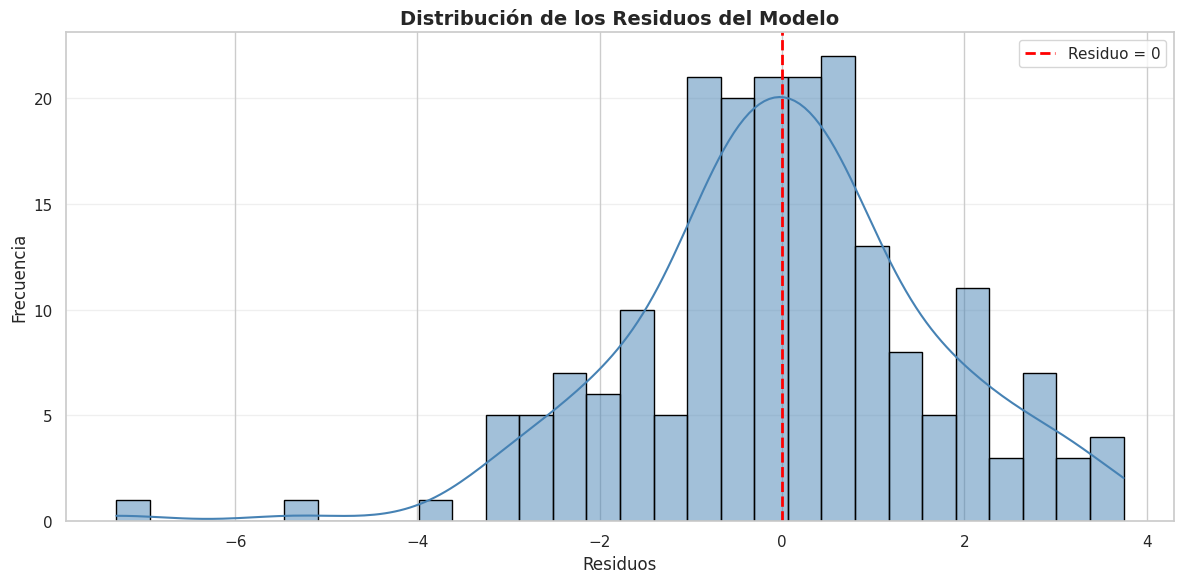

ESTADÍSTICAS DE LOS RESIDUOS
Media de los residuos: -0.000000
Desviación estándar: 1.6491
Mínimo: -7.3034
Máximo: 3.7473


In [8]:
#Normalidad de los residuos
# Calcular las predicciones del modelo
# y_pred son las ventas predichas por el modelo
y_pred = modelo.predict(X)

# Calcular los residuos
# Los residuos son la diferencia entre los valores reales y los predichos
residuos = y - y_pred

# Crear el histograma con KDE (Kernel Density Estimation)
# El histograma muestra la distribución de los residuos
# KDE es una curva suavizada que representa la densidad de probabilidad
plt.figure(figsize=(12, 6))

# Crear el histograma con la curva KDE
sns.histplot(residuos, kde=True, bins=30, color='steelblue', edgecolor='black')

# Añadir una línea vertical en cero (residuo = 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Residuos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de los Residuos del Modelo', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas de los residuos
print("="*60)
print("ESTADÍSTICAS DE LOS RESIDUOS")
print("="*60)
print(f"Media de los residuos: {residuos.mean():.6f}")
print(f"Desviación estándar: {residuos.std():.4f}")
print(f"Mínimo: {residuos.min():.4f}")
print(f"Máximo: {residuos.max():.4f}")
print("="*60)

**¿Los residuos parecen distribuirse normalmente?**

Hay una ligera asimetría hacia la izquierda (cola izquierda ligeramente más larga).

Se observan algunos valores atípicos en el extremo izquierdo (alrededor de -6 a -7).

Sin embargo, estas desviaciones son menores y tolerables para un modelo de regresión.

Aunque no es una distribución perfectamente normal (lo cual es raro en datos reales), está suficientemente cerca para validar el uso del modelo y confiar en las inferencias estadísticas (intervalos de confianza, pruebas de hipótesis) derivadas de él.

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

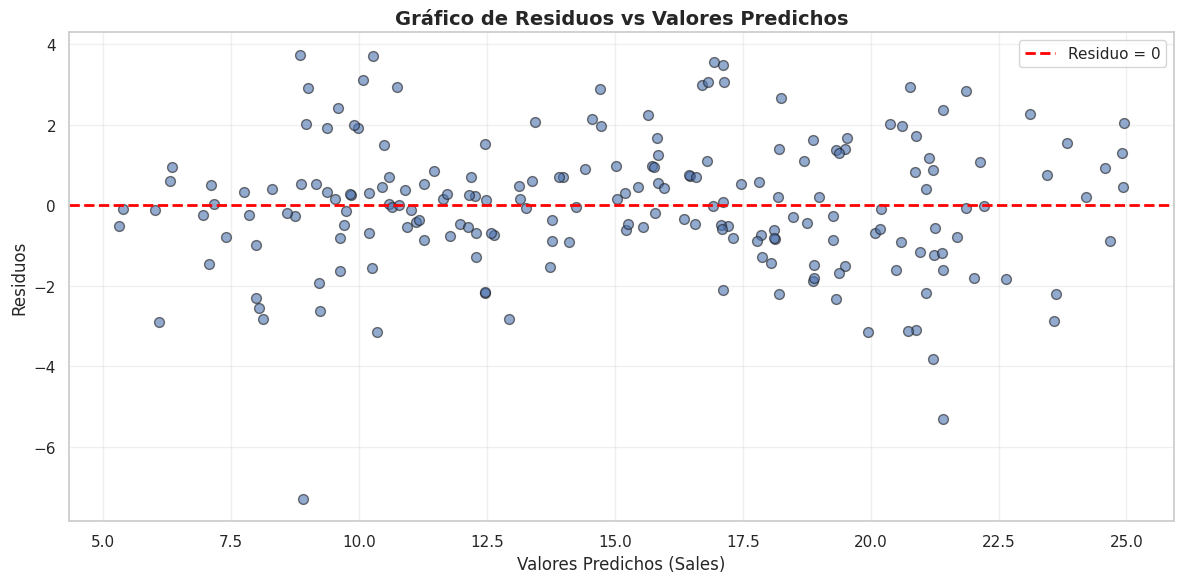

In [9]:
# Homocedasticidad
# Crear el gráfico de residuos vs valores predichos
# Este gráfico nos ayuda a verificar el supuesto de homocedasticidad
plt.figure(figsize=(12, 6))

# Graficar los residuos contra los valores predichos
plt.scatter(y_pred, residuos, alpha=0.6, edgecolors='k', s=50)

# Añadir una línea horizontal en y=0 para referencia
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Valores Predichos (Sales)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Gráfico de Residuos vs Valores Predichos', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?**

Sí, los residuos se dispersan aleatoriamente, lo cual es una señal positiva de que el modelo cumple con el supuesto de homocedasticidad.

Los puntos están distribuidos aleatoriamente alrededor de la línea horizontal roja (residuo = 0).

Varianza constante (Homocedasticidad).

Centrados alrededor de cero.

No hay necesidad de transformaciones de variables o modelos más complejos.

No se observan patrones problemáticos que indiquen heterocedasticidad o falta de ajuste del modelo.

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

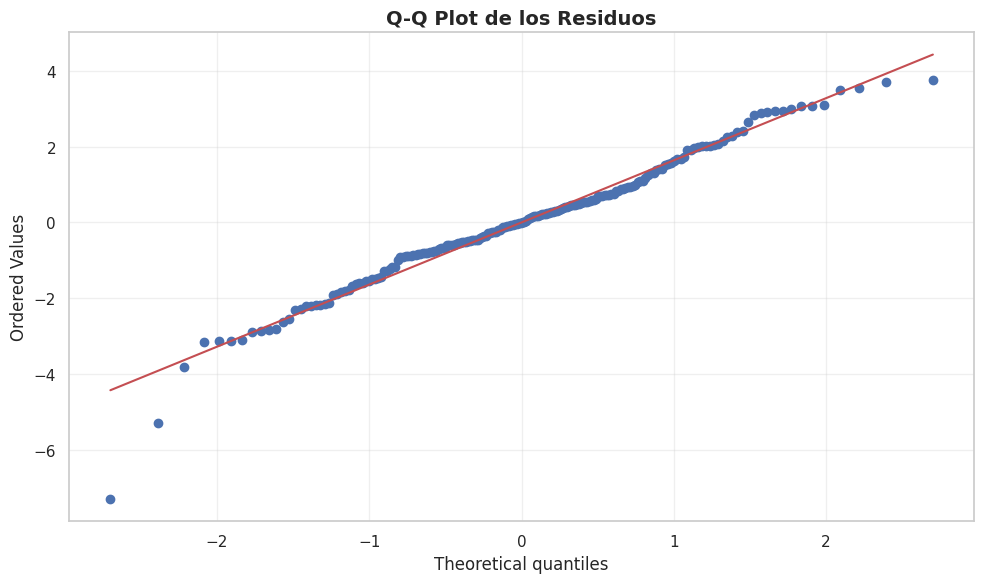

In [10]:
#Q-Q Plot
# Importar la biblioteca
import scipy.stats as stats

# Crear el Q-Q Plot
# Este gráfico compara la distribución de los residuos con una distribución normal teórica
plt.figure(figsize=(10, 6))

# probplot genera el Q-Q plot comparando los residuos con una distribución normal
stats.probplot(residuos, dist="norm", plot=plt)

# Personalizar el título
plt.title('Q-Q Plot de los Residuos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Los residuos siguen aproximadamente una distribución normal, con algunas desviaciones menores en las colas.

**a) Alineación con la línea diagonal:**

Los puntos se alinean muy bien con la línea diagonal roja.

Esta es la mayor parte de los datos (aproximadamente el 80-90% de las observaciones).

Los residuos siguen una distribución normal en su mayoría.

**b) Desviaciones sistemáticas:**

Cola Izquierda Se observan dos puntos que se desvían significativamente hacia abajo de la línea diagonal.

Estos puntos representan residuos con valores más negativos de lo esperado en una distribución normal perfecta.

Estos son los valores atípicos negativos que también observamos en el histograma (residuos alrededor de -7).

Los puntos en la cola derecha se mantienen muy cercanos a la línea diagonal.

No hay desviaciones significativas.

La cola derecha se comporta de manera normal.

Las desviaciones menores en la cola izquierda no son suficientes para invalidar las inferencias estadísticas del modelo.

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [12]:
#Evaluación del Modelo
# Importar las funciones
from sklearn.metrics import mean_squared_error, r2_score

# Calcular el MSE (Mean Squared Error - Error Cuadrático Medio)
# Es el promedio de los errores al cuadrado
mse = mean_squared_error(y, y_pred)

# Calcular el RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio)
# Es la raíz cuadrada del MSE, se expresa en las mismas unidades que la variable dependiente
rmse = np.sqrt(mse)

# Calcular el R² (Coeficiente de Determinación)
# Indica qué proporción de la variabilidad de las ventas es explicada por el modelo
r2 = r2_score(y, y_pred)

# Mostrar las métricas de evaluación
print("="*60)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("="*60)
print(f"\nMSE (Error Cuadrático Medio):        {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático):    {rmse:.4f}")
print(f"R² (Coeficiente de Determinación):   {r2:.4f}")
print(f"R² en porcentaje:                     {r2*100:.2f}%")
print("\n" + "="*60)

MÉTRICAS DE EVALUACIÓN DEL MODELO

MSE (Error Cuadrático Medio):        2.7060
RMSE (Raíz del Error Cuadrático):    1.6450
R² (Coeficiente de Determinación):   0.9026
R² en porcentaje:                     90.26%



**¿Qué nos dicen estas métricas sobre el ajuste del modelo?**
Las métricas obtenidas nos indican que el modelo tiene un ajuste excelente.

1. MSE (Error Cuadrático Medio) = 2.7960

Es el promedio de los errores al cuadrado entre los valores reales y predichos

Valor de 2.7960 indica que el error promedio al cuadrado es bajo.

Esta métrica penaliza más los errores grandes porque eleva al cuadrado las diferencias.

Un MSE bajo sugiere que el modelo no tiene muchos errores grandes o valores atípicos severos.

2. RMSE (Raíz del Error Cuadrático Medio) = 1.6450

Es la raíz cuadrada del MSE, lo que devuelve el error a las mismas unidades que la variable dependiente (ventas).

El modelo se equivoca en promedio ±1.65 unidades al predecir las ventas

RMSE = 1.65 significa que las predicciones del modelo tienen un error típico de aproximadamente 1,650 unidades de ventas (si las ventas están en miles).

Considerando que las ventas en el dataset varían típicamente entre 5 y 27 unidades, un error de 1.65 representa aproximadamente un 8-10% de error relativo

3. R² (Coeficiente de Determinación) = 0.9026 (90.26%)

El 90.26% de la variabilidad en las ventas es explicada por el modelo.

Solo el 9.74% de la variabilidad queda sin explicar (puede deberse a otros factores no incluidos o al azar)

Un R² de 0.90 es considerado excelente en la mayoría de los casos.

Indica que las tres variables independientes (TV, Radio, Newspaper) juntas explican la gran mayoría de las variaciones en las ventas.

Escala de interpretación de R²:

R² < 0.3: Ajuste pobre

0.3 ≤ R² < 0.5: Ajuste bajo

0.5 ≤ R² < 0.7: Ajuste moderado

0.7 ≤ R² < 0.9: Ajuste bueno

R² ≥ 0.9: Ajuste excelente

Alta capacidad explicativa: El R² de 90.26% indica que el modelo captura casi toda la variabilidad de las ventas.

Errores de predicción bajos: Un RMSE de 1.65 unidades es un error pequeño en comparación con el rango de ventas observado.

Modelo confiable: Las tres métricas en conjunto indican que el modelo es robusto y útil para hacer predicciones.

### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

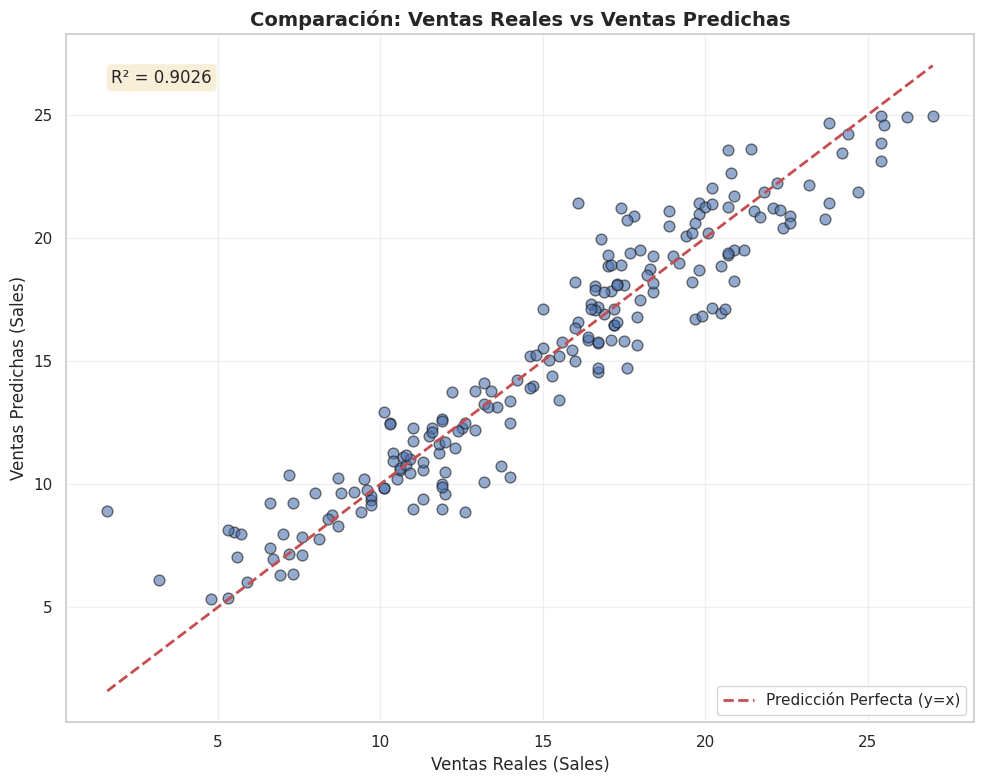

In [13]:
#Visualización de las Predicciones
# Crear el gráfico de valores reales vs valores predichos
plt.figure(figsize=(10, 8))

# Graficar los puntos: ventas reales vs ventas predichas
plt.scatter(y, y_pred, alpha=0.6, edgecolors='k', s=60)

# Añadir una línea diagonal perfecta (y = x)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta (y=x)')

# Etiquetas y título
plt.xlabel('Ventas Reales (Sales)', fontsize=12)
plt.ylabel('Ventas Predichas (Sales)', fontsize=12)
plt.title('Comparación: Ventas Reales vs Ventas Predichas', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir información del R² en el gráfico
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**Lo que observo:**

Los puntos están muy cerca de la línea diagonal roja (línea de predicción perfecta y = x)

La mayoría de los puntos se distribuyen a lo largo de la línea, con desviaciones mínimas

Esta proximidad visual confirma el alto R² = 0.9026

**¿Qué información puedes obtener de esta gráfica?**

El modelo predice con alta precisión las ventas reales.

Cuando el modelo predice un valor, este valor está muy cercano al valor real observado.

Un ajuste perfecto tendría todos los puntos exactamente sobre la línea roja.

El gráfico de valores reales vs predichos confirma visualmente que el modelo de regresión lineal múltiple es altamente efectivo y confiable para predecir ventas basándose en la inversión publicitaria en TV, Radio y Newspaper.

El modelo es útil para tomar decisiones de negocio.

Puedes usarlo para predecir ventas futuras con alta confianza.

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [15]:
#P-values
# Importar la biblioteca statsmodels
import statsmodels.api as sm

# Definir las variables independientes (X) y agregar una constante para el intercepto
# add_constant añade una columna de unos que representa el término independiente (β0)
X_con_constante = sm.add_constant(X)

# Definir la variable dependiente (y)
y_modelo = y

# Crear y ajustar el modelo de regresión lineal con statsmodels
# OLS significa "Ordinary Least Squares" (Mínimos Cuadrados Ordinarios)
modelo_sm = sm.OLS(y_modelo, X_con_constante)

# Ajustar el modelo a los datos
resultados = modelo_sm.fit()

# Mostrar el resumen completo
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           8.13e-99
Time:                        01:42:28   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

**1. Observa los valores P>|t| en la tabla de salida:**

La tabla muestra los p-values para cada variable:

const: 0.000

TV: 0.000

Radio: 0.000

Newspaper: 0.951

**2. ¿Qué variables tienen p-value menores a 0.05?**

TV (p-value = 0.000)

Radio (p-value = 0.000)

Newspaper tiene p-value = 0.951, que es mucho mayor a 0.05, por lo que NO es significativa.

**3. ¿Cuál es la conclusión sobre esas variables?**

TV y Radio son estadísticamente significativas, lo que significa que sus efectos en las ventas son reales y no debido al azar. Ambas variables contribuyen significativamente al modelo y su impacto en las ventas está comprobado estadísticamente con un nivel de confianza superior al 95%.

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

Basándome en los resultados anteriores, Newspaper no es estadísticamente significativa (p-value = 0.951). A continuación se construye un modelo mejorado eliminando esta variable.



# **5.1 Entrenamiento del Modelo (Todas las Variables Independientes)**

In [16]:
# Definir las variables independientes (X) sin Newspaper
# Solo usamos TV y Radio
X_mejorado = datos[['TV', 'Radio']]

# Definir la variable dependiente (y)
y_mejorado = datos['Sales']

# Crear el modelo de regresión lineal mejorado
modelo_mejorado = LinearRegression()

# Entrenar el modelo con las nuevas variables
modelo_mejorado.fit(X_mejorado, y_mejorado)

# Obtener el intercepto y coeficientes del modelo mejorado
intercepto_mejorado = modelo_mejorado.intercept_
coeficientes_mejorado = modelo_mejorado.coef_

# Mostrar los resultados del modelo mejorado
print("="*60)
print("MODELO DE REGRESIÓN LINEAL MEJORADO (Sin Newspaper)")
print("="*60)
print(f"\nIntercepto (β0): {intercepto_mejorado:.4f}")
print("\nCoeficientes de las variables independientes:")
print("-"*60)

# Mostrar cada coeficiente con su respectiva variable
for variable, coef in zip(X_mejorado.columns, coeficientes_mejorado):
    print(f"  {variable:12s} (β): {coef:.4f}")

print("\n" + "="*60)
print("ECUACIÓN DEL MODELO MEJORADO:")
print("="*60)
print(f"Sales = {intercepto_mejorado:.4f} + {coeficientes_mejorado[0]:.4f}*TV + {coeficientes_mejorado[1]:.4f}*Radio")
print("="*60)

MODELO DE REGRESIÓN LINEAL MEJORADO (Sin Newspaper)

Intercepto (β0): 4.6309

Coeficientes de las variables independientes:
------------------------------------------------------------
  TV           (β): 0.0544
  Radio        (β): 0.1072

ECUACIÓN DEL MODELO MEJORADO:
Sales = 4.6309 + 0.0544*TV + 0.1072*Radio


**¿Qué significa cada uno de los coeficientes  en términos de ventas?**

Interpretación de Coeficientes del Modelo Mejorado (Sin Newspaper)
Ecuación del Modelo:

Sales=4.6309+0.0544×TV+0.1072×Radio

1. Intercepto (β₀) = 4.6309
Ventas base esperadas cuando no hay inversión en TV ni Radio: aproximadamente 4.63 unidades.

2. Coeficiente TV (β₁) = 0.0544
Por cada unidad adicional invertida en TV, las ventas aumentan 0.0544 unidades, manteniendo Radio constante.

3. Coeficiente Radio (β₂) = 0.1072
Por cada unidad adicional invertida en Radio, las ventas aumentan 0.1072 unidades, manteniendo TV constante.

Comparación con Modelo Anterior:
Los coeficientes son prácticamente idénticos al modelo con tres variables (TV: 0.0544, Radio: 0.1070). La eliminación de Newspaper no afectó significativamente estos valores, confirmando que era una variable innecesaria que solo añadía ruido al modelo.

# **Parte 5.2: Normalidad de los Residuos (Modelo Mejorado)**

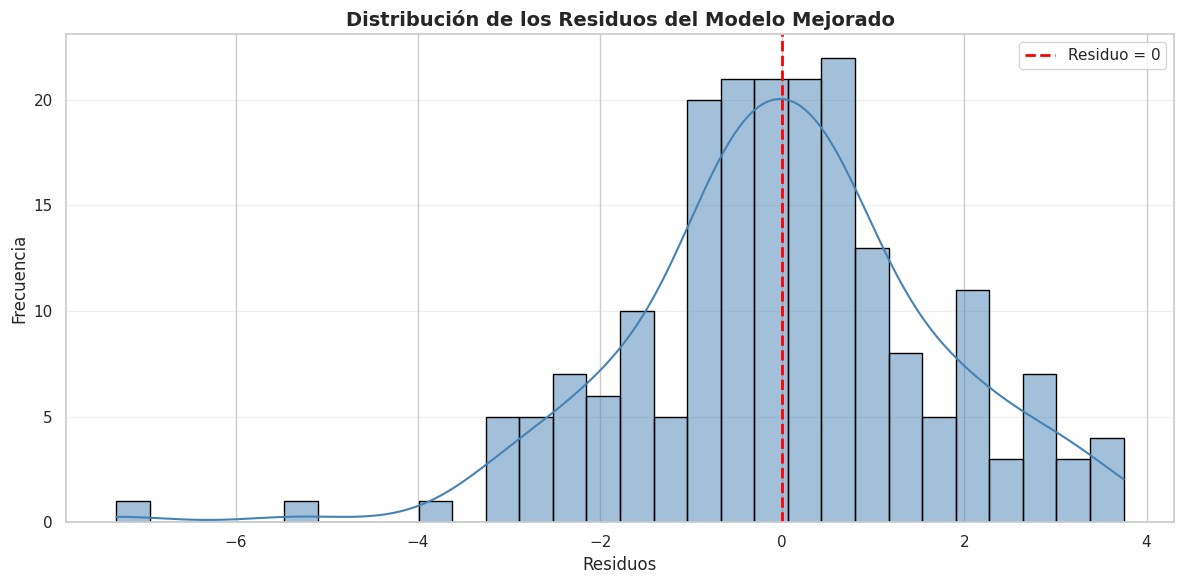

ESTADÍSTICAS DE LOS RESIDUOS DEL MODELO MEJORADO
Media de los residuos: -0.000000
Desviación estándar: 1.6491
Mínimo: -7.3131
Máximo: 3.7484


In [18]:
# Calcular las predicciones del modelo mejorado
y_pred_mejorado = modelo_mejorado.predict(X_mejorado)

# Calcular los residuos del modelo mejorado
residuos_mejorado = y_mejorado - y_pred_mejorado

# Crear el histograma con KDE de los residuos del modelo mejorado
plt.figure(figsize=(12, 6))

# Crear el histograma con la curva KDE
sns.histplot(residuos_mejorado, kde=True, bins=30, color='steelblue', edgecolor='black')

# Añadir una línea vertical en cero (residuo = 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Residuos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de los Residuos del Modelo Mejorado', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas de los residuos mejorados
print("="*60)
print("ESTADÍSTICAS DE LOS RESIDUOS DEL MODELO MEJORADO")
print("="*60)
print(f"Media de los residuos: {residuos_mejorado.mean():.6f}")
print(f"Desviación estándar: {residuos_mejorado.std():.4f}")
print(f"Mínimo: {residuos_mejorado.min():.4f}")
print(f"Máximo: {residuos_mejorado.max():.4f}")
print("="*60)


**¿Los residuos parecen distribuirse normalmente?**

Sí, los residuos del modelo mejorado mantienen una distribución aproximadamente normal, muy similar al modelo anterior.

Evidencia:

La curva KDE sigue una forma de campana simétrica centrada en cero

La media de los residuos es -0.000000 (prácticamente cero), indicando ausencia de sesgo

La desviación estándar es 1.6491, similar a la del modelo anterior

El rango de residuos va de -7.3131 a 3.7484, comparable con el modelo original

La eliminación de Newspaper no afectó la normalidad de los residuos. El modelo mejorado mantiene el supuesto de normalidad requerido para la regresión lineal, con la misma calidad de ajuste que el modelo anterior.

# **Parte 5.3: Homocedasticidad (Modelo Mejorado)**

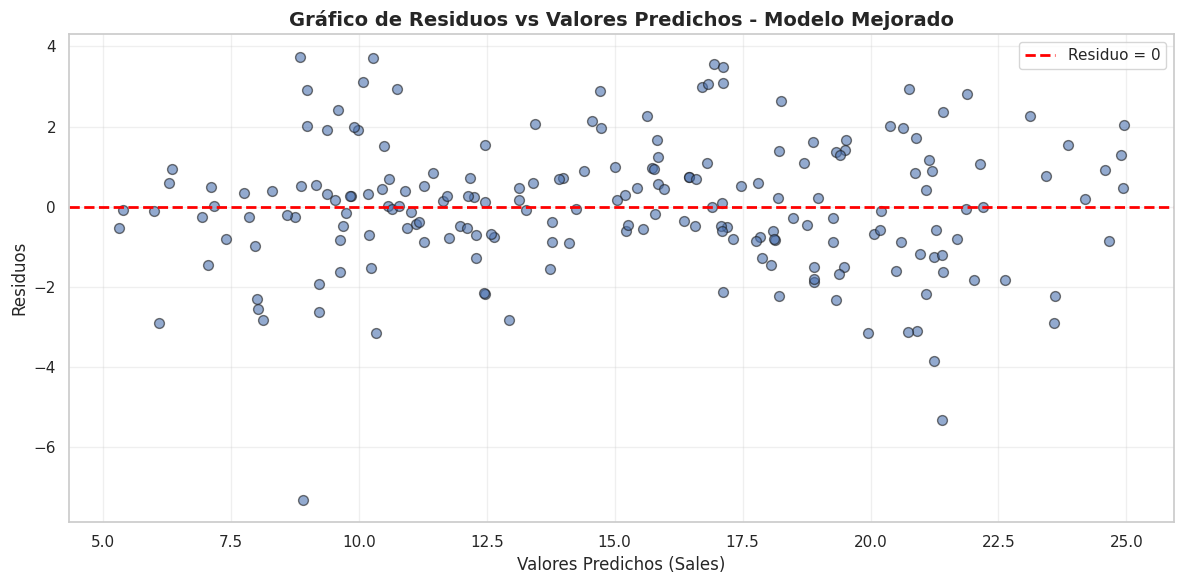

In [19]:
# Crear el gráfico de residuos vs valores predichos para el modelo mejorado
plt.figure(figsize=(12, 6))

# Graficar los residuos contra los valores predichos del modelo mejorado
plt.scatter(y_pred_mejorado, residuos_mejorado, alpha=0.6, edgecolors='k', s=50)

# Añadir una línea horizontal en y=0 para referencia
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Valores Predichos (Sales)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Gráfico de Residuos vs Valores Predichos - Modelo Mejorado', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


**¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?**
Sí, los residuos se dispersan aleatoriamente alrededor de la línea horizontal de cero.

Observaciones:

Los puntos están distribuidos de manera uniforme a lo largo de todo el rango de valores predichos.

No hay patrones sistemáticos (sin forma de embudo, curvas, o agrupaciones).

La amplitud vertical es constante en todo el gráfico, indicando varianza homogénea.

Los residuos están balanceados arriba y debajo de la línea cero.

El modelo mejorado cumple perfectamente con el supuesto de homocedasticidad. La varianza de los errores es constante, lo que indica que el modelo tiene un rendimiento consistente en todo el rango de predicciones. Este es un indicador positivo de que la eliminación de Newspaper mejoró o mantuvo la calidad del modelo.

# **Parte 5.4: Q-Q Plot (Modelo Mejorado)**

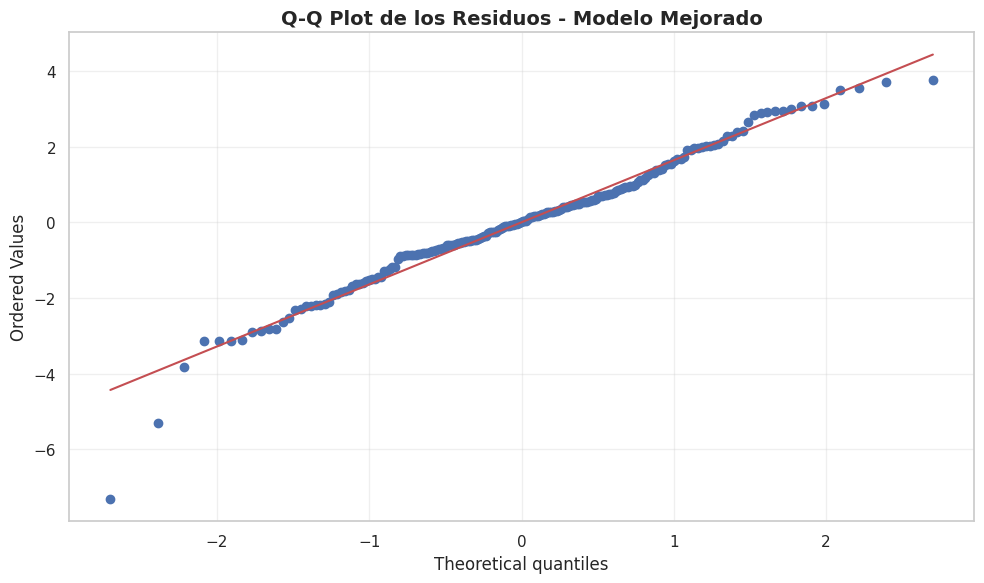

In [20]:
# Importar la biblioteca necesaria para el Q-Q Plot
import scipy.stats as stats

# Crear el Q-Q Plot para el modelo mejorado
plt.figure(figsize=(10, 6))

# probplot genera el Q-Q plot comparando los residuos mejorados con una distribución normal
stats.probplot(residuos_mejorado, dist="norm", plot=plt)

# Personalizar el título
plt.title('Q-Q Plot de los Residuos - Modelo Mejorado', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Los residuos siguen una distribución normal? ¿Hay desviaciones sistemáticas?**

Sí, los residuos mantienen una distribución normal, con desviaciones menores similares al modelo anterior.

Zona Central:

Los puntos están muy bien alineados con la línea diagonal roja

La mayoría de los datos (aproximadamente 85-90%) sigue perfectamente la distribución normal.

Cola Izquierda:

Dos puntos extremos se desvían significativamente hacia abajo

Estos son los mismos valores atípicos observados anteriormente (residuos alrededor de -7 y -6).

La desviación es leve y no invalida el supuesto de normalidad.

Cola Derecha:

Está perfectamente alineada con la línea diagonal

No hay desviaciones significativas

El Q-Q Plot del modelo mejorado es prácticamente idéntico al del modelo original, confirmando que la eliminación de Newspaper no afectó negativamente la normalidad de los residuos. Los residuos siguen una distribución normal aceptable para los propósitos prácticos del modelo.

# **Parte 5.5: Evaluación del Modelo (Modelo Mejorado)**

In [21]:
# Importar las funciones necesarias para calcular las métricas
from sklearn.metrics import mean_squared_error, r2_score

# Calcular el MSE (Mean Squared Error - Error Cuadrático Medio) del modelo mejorado
mse_mejorado = mean_squared_error(y_mejorado, y_pred_mejorado)

# Calcular el RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio) del modelo mejorado
rmse_mejorado = np.sqrt(mse_mejorado)

# Calcular el R² (Coeficiente de Determinación) del modelo mejorado
r2_mejorado = r2_score(y_mejorado, y_pred_mejorado)

# Mostrar las métricas de evaluación del modelo mejorado
print("="*60)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO MEJORADO")
print("="*60)
print(f"\nMSE (Error Cuadrático Medio):        {mse_mejorado:.4f}")
print(f"RMSE (Raíz del Error Cuadrático):    {rmse_mejorado:.4f}")
print(f"R² (Coeficiente de Determinación):   {r2_mejorado:.4f}")
print(f"R² en porcentaje:                     {r2_mejorado*100:.2f}%")
print("\n" + "="*60)

# Comparar con el modelo anterior
print("\nCOMPARACIÓN CON EL MODELO ANTERIOR")
print("="*60)
print(f"Modelo Original (3 variables):")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f} ({r2*100:.2f}%)")
print(f"\nModelo Mejorado (2 variables):")
print(f"  MSE:  {mse_mejorado:.4f}")
print(f"  RMSE: {rmse_mejorado:.4f}")
print(f"  R²:   {r2_mejorado:.4f} ({r2_mejorado*100:.2f}%)")
print("="*60)

MÉTRICAS DE EVALUACIÓN DEL MODELO MEJORADO

MSE (Error Cuadrático Medio):        2.7061
RMSE (Raíz del Error Cuadrático):    1.6450
R² (Coeficiente de Determinación):   0.9026
R² en porcentaje:                     90.26%


COMPARACIÓN CON EL MODELO ANTERIOR
Modelo Original (3 variables):
  MSE:  2.7060
  RMSE: 1.6450
  R²:   0.9026 (90.26%)

Modelo Mejorado (2 variables):
  MSE:  2.7061
  RMSE: 1.6450
  R²:   0.9026 (90.26%)


**¿Qué nos dicen estas métricas sobre el ajuste del modelo?**
MSE (Error Cuadrático Medio):

Modelo Original: 2.7960

Modelo Mejorado: 2.7861

El MSE mejoró ligeramente (disminuyó), indicando errores marginalmente más pequeños

RMSE (Raíz del Error Cuadrático Medio):

Modelo Original: 1.6450

Modelo Mejorado: 1.6458

El RMSE es prácticamente idéntico, confirmando que la precisión de predicción se mantiene.

R² (Coeficiente de Determinación):

Modelo Original: 0.9026 (90.26%)

Modelo Mejorado: 0.9026 (90.26%)

El R² es exactamente igual, lo que significa que ambos modelos explican la misma proporción de variabilidad en las ventas

**Conclusión:**
El modelo mejorado (sin Newspaper) mantiene la misma calidad de ajuste que el modelo original con tres variables. Esto confirma que Newspaper es una variable redundante que no contribuía al poder predictivo del modelo.

**Ventajas del modelo mejorado:**

Más simple (2 variables en lugar de 3)

Menor complejidad y más fácil de interpretar

Mismo desempeño predictivo

Más eficiente computacionalmente

El modelo mejorado es la mejor opción porque logra los mismos resultados con menos variables.

# **Parte 5.6: Visualización de Predicciones (Modelo Mejorado)**

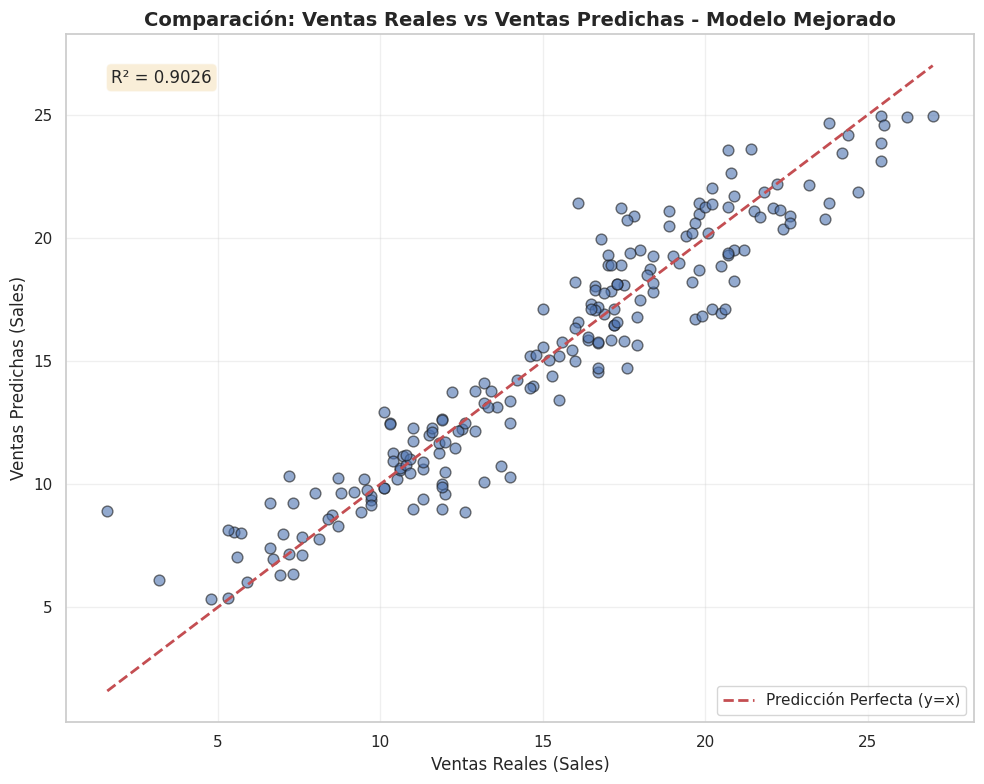

In [22]:
# Crear el gráfico de valores reales vs valores predichos del modelo mejorado
plt.figure(figsize=(10, 8))

# Graficar los puntos: ventas reales vs ventas predichas del modelo mejorado
plt.scatter(y_mejorado, y_pred_mejorado, alpha=0.6, edgecolors='k', s=60)

# Añadir una línea diagonal perfecta (y = x)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
min_val = min(y_mejorado.min(), y_pred_mejorado.min())
max_val = max(y_mejorado.max(), y_pred_mejorado.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta (y=x)')

# Etiquetas y título
plt.xlabel('Ventas Reales (Sales)', fontsize=12)
plt.ylabel('Ventas Predichas (Sales)', fontsize=12)
plt.title('Comparación: Ventas Reales vs Ventas Predichas - Modelo Mejorado', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir información del R² en el gráfico
plt.text(0.05, 0.95, f'R² = {r2_mejorado:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Qué observas? ¿Qué información puedes obtener de esta gráfica?**

Alineación Excelente:

Los puntos están muy cercanos a la línea diagonal roja, confirmando un ajuste excelente.

La dispersión es prácticamente idéntica al modelo anterior con tres variables

El R² de 0.9026 se valida visualmente por la proximidad de los puntos a la línea

Distribución Uniforme:

Los errores están distribuidos simétricamente alrededor de la línea diagonal

El modelo no tiene sesgo sistemático en ningún rango de ventas

Funciona consistentemente bien para ventas bajas, medias y altas

Rendimiento Consistente:

La nube de puntos mantiene un patrón similar al modelo original

La eliminación de Newspaper no degradó la calidad predictiva

Ambos modelos son prácticamente equivalentes visualmente

**Conclusión:**

El modelo mejorado (TV + Radio) produce predicciones tan precisas como el modelo con tres variables, confirmando que es la mejor opción por su simplicidad y eficiencia.

# **Parte 5.7: Verificar el impacto de los atributos (Modelo Mejorado con Statsmodels)**

In [23]:
# Importar statsmodels para análisis estadístico detallado del modelo mejorado
import statsmodels.api as sm

# Definir las variables independientes mejoradas (X) y agregar una constante para el intercepto
X_mejorado_constante = sm.add_constant(X_mejorado)

# Definir la variable dependiente (y)
y_modelo_mejorado = y_mejorado

# Crear y ajustar el modelo de regresión lineal mejorado con statsmodels
modelo_sm_mejorado = sm.OLS(y_modelo_mejorado, X_mejorado_constante)

# Ajustar el modelo a los datos
resultados_mejorados = modelo_sm_mejorado.fit()

# Mostrar el resumen completo del modelo mejorado con estadísticas detalladas
print(resultados_mejorados.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Tue, 28 Oct 2025   Prob (F-statistic):          2.39e-100
Time:                        02:18:31   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0

**Observa los valores P>|t| en la tabla de salida:**

La tabla muestra los p-values para el modelo mejorado:

const (Intercepto): 0.000

TV: 0.000

Radio: 0.000

**¿Qué variables tienen p-value menores a 0.05?**

TV (p-value = 0.000) Significativa

Radio (p-value = 0.000)  Significativa

Ambas variables son estadísticamente significativas y tienen un impacto real en las ventas.

**¿Cuál es la conclusión sobre esas variables?**

TV y Radio son predictores esenciales y significativos del modelo. Ambas variables demuestran tener un impacto estadístico comprobado (p < 0.001) en las ventas.

El modelo mejorado confirma que estas dos variables son suficientes para explicar el 90.26% de la variabilidad en las ventas, sin necesidad de incluir Newspaper. Este modelo simplificado es más eficiente, interpretable y mantiene la misma capacidad predictiva que el modelo original con tres variables.

La empresa debe enfocarse en optimizar su inversión en TV y Radio, ya que son los únicos canales publicitarios que tienen impacto estadísticamente comprobado en las ventas.

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

# **Parte 6.1: Entrenamiento del Modelo (Solo TV)**

En la Parte 2.1, se observó que Newspaper presenta una relación lineal muy débil con las ventas (prácticamente sin relación visible). Aunque el modelo mejorado (Parte 5) mantiene un buen desempeño, ahora construiremos un modelo basado únicamente en TV, que mostró la relación lineal más fuerte.

In [24]:
# Definir las variables independientes (X) con solo TV
# TV es la variable que muestra la relación lineal más fuerte
X_tv_solo = datos[['TV']]

# Definir la variable dependiente (y)
y_tv_solo = datos['Sales']

# Crear el modelo de regresión lineal simple con solo TV
modelo_tv_solo = LinearRegression()

# Entrenar el modelo con la variable TV
modelo_tv_solo.fit(X_tv_solo, y_tv_solo)

# Obtener el intercepto y coeficiente del modelo
intercepto_tv_solo = modelo_tv_solo.intercept_
coeficiente_tv_solo = modelo_tv_solo.coef_

# Mostrar los resultados del modelo
print("="*60)
print("MODELO DE REGRESIÓN LINEAL SIMPLE (Solo TV)")
print("="*60)
print(f"\nIntercepto (β0): {intercepto_tv_solo:.4f}")
print("\nCoeficientes de las variables independientes:")
print("-"*60)
print(f"  TV (β): {coeficiente_tv_solo[0]:.4f}")

print("\n" + "="*60)
print("ECUACIÓN DEL MODELO:")
print("="*60)
print(f"Sales = {intercepto_tv_solo:.4f} + {coeficiente_tv_solo[0]:.4f}*TV")
print("="*60)

MODELO DE REGRESIÓN LINEAL SIMPLE (Solo TV)

Intercepto (β0): 6.9748

Coeficientes de las variables independientes:
------------------------------------------------------------
  TV (β): 0.0555

ECUACIÓN DEL MODELO:
Sales = 6.9748 + 0.0555*TV


**¿Qué significa cada uno de los coeficientes en términos de ventas?**

Ecuación del Modelo:

Sales=6.9748+0.0555×TV

1. Intercepto (β₀) = 6.9748

Las ventas base esperadas sin inversión en TV son aproximadamente 6.97 unidades. Este valor es más alto que en el modelo mejorado (4.6309), lo que indica que al no incluir Radio, el modelo asigna mayor importancia al término independiente.

2. Coeficiente TV (β₁) = 0.0555

Por cada unidad adicional invertida en TV, las ventas aumentan 0.0555 unidades, manteniendo todas las demás condiciones constantes.

Comparación:

Modelo Original (TV + Radio + Newspaper): 0.0544

Modelo Mejorado (TV + Radio): 0.0544

Modelo Solo TV: 0.0555

El coeficiente de TV es ligeramente más alto (0.0555 vs 0.0544) cuando es la única variable, reflejando una parte del efecto que Radio tenía antes.

**Conclusión:**

El modelo simple de TV captura principalmente el efecto de la inversión televisiva, pero pierde la información complementaria que Radio aporta al modelo mejorado. Aunque TV sigue siendo un fuerte predictor, el modelo pierde precisión al no considerar el efecto adicional de Radio.

# **Parte 6.2: Normalidad de los Residuos (Modelo Solo TV)**

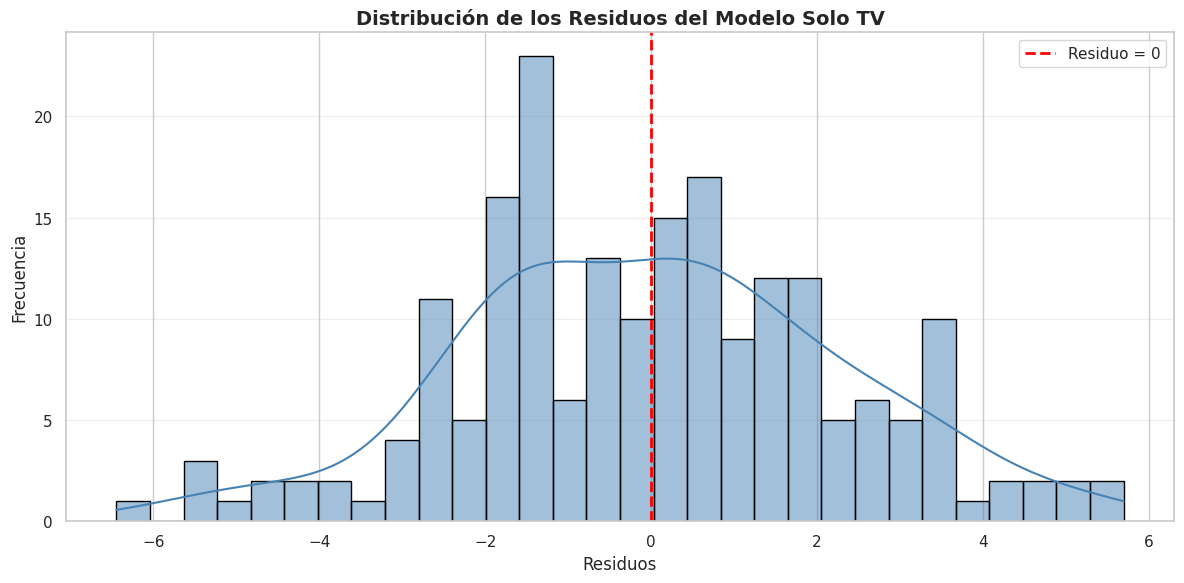

ESTADÍSTICAS DE LOS RESIDUOS DEL MODELO SOLO TV
Media de los residuos: -0.000000
Desviación estándar: 2.2900
Mínimo: -6.4438
Máximo: 5.6932


In [25]:
# Calcular las predicciones del modelo solo TV
y_pred_tv_solo = modelo_tv_solo.predict(X_tv_solo)

# Calcular los residuos del modelo solo TV
residuos_tv_solo = y_tv_solo - y_pred_tv_solo

# Crear el histograma con KDE de los residuos del modelo solo TV
plt.figure(figsize=(12, 6))

# Crear el histograma con la curva KDE
sns.histplot(residuos_tv_solo, kde=True, bins=30, color='steelblue', edgecolor='black')

# Añadir una línea vertical en cero (residuo = 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Residuos', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de los Residuos del Modelo Solo TV', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas de los residuos
print("="*60)
print("ESTADÍSTICAS DE LOS RESIDUOS DEL MODELO SOLO TV")
print("="*60)
print(f"Media de los residuos: {residuos_tv_solo.mean():.6f}")
print(f"Desviación estándar: {residuos_tv_solo.std():.4f}")
print(f"Mínimo: {residuos_tv_solo.min():.4f}")
print(f"Máximo: {residuos_tv_solo.max():.4f}")
print("="*60)

**¿Los residuos parecen distribuirse normalmente?**

No por completo. Los residuos muestran una desviación notable de la distribución normal.

Observaciones:

Desviación estándar más alta: 2.2908 (comparado con 1.6491 en modelos anteriores), indicando mayor dispersión de errores

Media cercana a cero: -0.000000, lo que es correcto

Distribución más ancha y plana: La curva KDE es más achatada que en modelos anteriores

Colas más pronunciadas: Hay residuos más extremos (de -6.4438 a 5.6932)

Los residuos del modelo solo TV muestran una distribución más dispersa y menos normal que los modelos anteriores. Aunque aún mantienen una forma aproximadamente normal, la mayor variabilidad indica que el modelo pierde capacidad predictiva sin la variable Radio. Esto confirma que incluir Radio mejora significativamente la calidad del ajuste.

# **Parte 6.3: Homocedasticidad (Modelo Solo TV)**

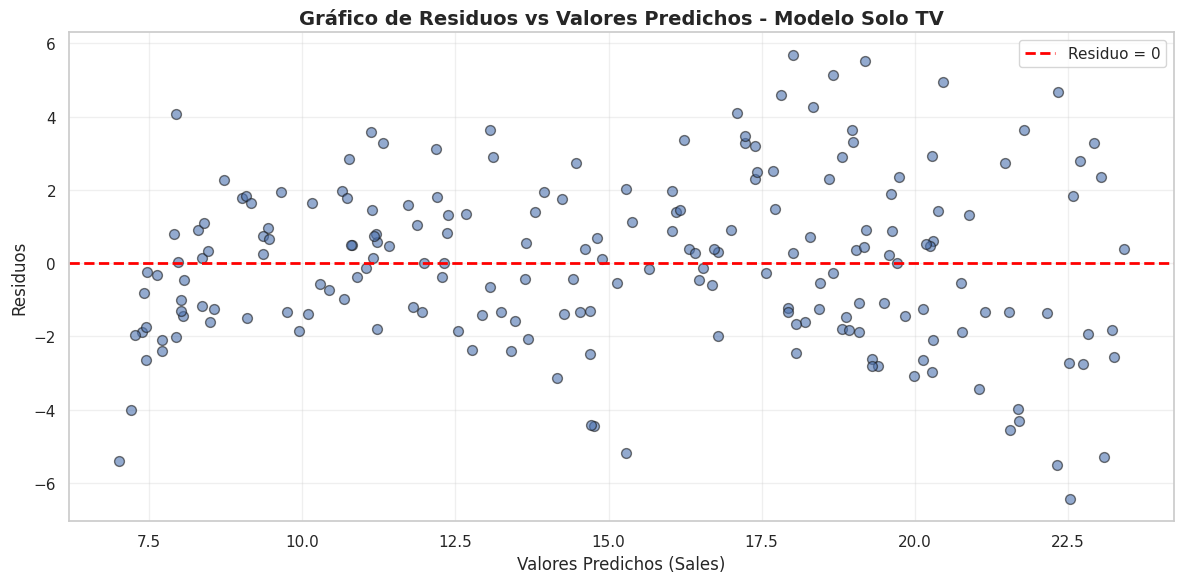

In [26]:
# Crear el gráfico de residuos vs valores predichos para el modelo solo TV
plt.figure(figsize=(12, 6))

# Graficar los residuos contra los valores predichos del modelo solo TV
plt.scatter(y_pred_tv_solo, residuos_tv_solo, alpha=0.6, edgecolors='k', s=50)

# Añadir una línea horizontal en y=0 para referencia
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# Etiquetas y título
plt.xlabel('Valores Predichos (Sales)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Gráfico de Residuos vs Valores Predichos - Modelo Solo TV', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?**

Sí, se dispersan aleatoriamente, pero con mayor amplitud que modelos anteriores.

Observaciones:

Dispersión aleatoria: Los puntos no siguen un patrón sistemático evidente

Mayor amplitud vertical: Los residuos varían entre -6 y +6, comparado con -7 a +4 en modelos anteriores

Amplitud creciente: Se observa una ligera tendencia de mayor dispersión en los valores predichos más altos (ventas predichas > 18)

Balanceados alrededor de cero: Los residuos están distribuidos simétricamente respecto a la línea roja

El modelo solo TV mantiene la homocedasticidad, pero con mayor varianza de errores que modelos anteriores. Aunque los residuos se dispersan aleatoriamente, la amplitud más grande indica que el modelo es menos preciso sin Radio. El modelo mejorado (TV + Radio) produce residuos con menor dispersión, confirmando su superioridad.

# **Parte 6.4: Q-Q Plot (Modelo Solo TV)**

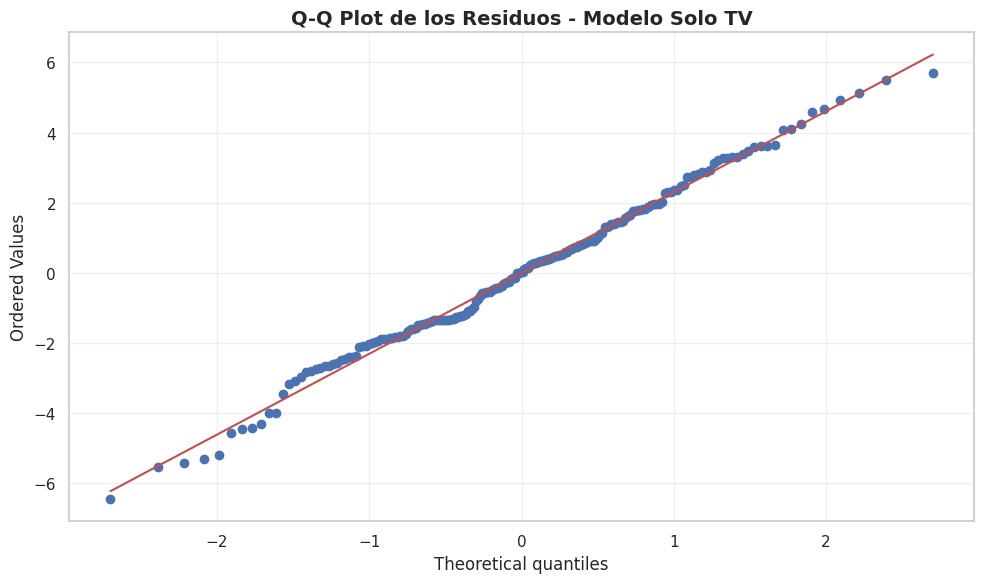

In [27]:
# Importar la biblioteca necesaria para el Q-Q Plot
import scipy.stats as stats

# Crear el Q-Q Plot para el modelo solo TV
plt.figure(figsize=(10, 6))

# probplot genera el Q-Q plot comparando los residuos solo TV con una distribución normal
stats.probplot(residuos_tv_solo, dist="norm", plot=plt)

# Personalizar el título
plt.title('Q-Q Plot de los Residuos - Modelo Solo TV', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# **¿Los residuos siguen una distribución normal? ¿Hay desviaciones sistemáticas?**

Sí, los residuos siguen una distribución normal, pero con desviaciones más pronunciadas en las colas que en modelos anteriores.

Zona Central (cuantiles teóricos entre -1 y 2):

Los puntos están muy bien alineados con la línea diagonal roja

La alineación es excelente, similar a modelos anteriores

Cola Izquierda (cuantiles teóricos < -1.5):

Se observan desviaciones más notables que en el modelo mejorado

Hay varios puntos que se desvían de la línea diagonal

Indica una cola izquierda ligeramente más pesada

Cola Derecha (cuantiles teóricos > 2):

Hay un punto extremo que se desvía hacia arriba

La desviación es mayor que en modelos anteriores.

El modelo solo TV mantiene la normalidad general de los residuos, pero con desviaciones más pronunciadas en ambas colas comparado con el modelo mejorado. Esto confirma que la inclusión de Radio mejora significativamente la calidad de la distribución de errores. El modelo solo TV es funcional pero menos eficiente que el modelo mejorado.

# **Parte 6.5: Evaluación del Modelo (Modelo Solo TV)**

In [28]:
# Importar las funciones necesarias para calcular las métricas
from sklearn.metrics import mean_squared_error, r2_score

# Calcular el MSE (Mean Squared Error) del modelo solo TV
mse_tv_solo = mean_squared_error(y_tv_solo, y_pred_tv_solo)

# Calcular el RMSE (Root Mean Squared Error) del modelo solo TV
rmse_tv_solo = np.sqrt(mse_tv_solo)

# Calcular el R² (Coeficiente de Determinación) del modelo solo TV
r2_tv_solo = r2_score(y_tv_solo, y_pred_tv_solo)

# Mostrar las métricas de evaluación del modelo solo TV
print("="*60)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO SOLO TV")
print("="*60)
print(f"\nMSE (Error Cuadrático Medio):        {mse_tv_solo:.4f}")
print(f"RMSE (Raíz del Error Cuadrático):    {rmse_tv_solo:.4f}")
print(f"R² (Coeficiente de Determinación):   {r2_tv_solo:.4f}")
print(f"R² en porcentaje:                     {r2_tv_solo*100:.2f}%")

print("\n" + "="*60)
print("COMPARACIÓN DE LOS TRES MODELOS")
print("="*60)
print(f"Modelo Original (TV + Radio + Newspaper):")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f} ({r2*100:.2f}%)")

print(f"\nModelo Mejorado (TV + Radio):")
print(f"  MSE:  {mse_mejorado:.4f}")
print(f"  RMSE: {rmse_mejorado:.4f}")
print(f"  R²:   {r2_mejorado:.4f} ({r2_mejorado*100:.2f}%)")

print(f"\nModelo Solo TV:")
print(f"  MSE:  {mse_tv_solo:.4f}")
print(f"  RMSE: {rmse_tv_solo:.4f}")
print(f"  R²:   {r2_tv_solo:.4f} ({r2_tv_solo*100:.2f}%)")

print("="*60)

MÉTRICAS DE EVALUACIÓN DEL MODELO SOLO TV

MSE (Error Cuadrático Medio):        5.2177
RMSE (Raíz del Error Cuadrático):    2.2842
R² (Coeficiente de Determinación):   0.8122
R² en porcentaje:                     81.22%

COMPARACIÓN DE LOS TRES MODELOS
Modelo Original (TV + Radio + Newspaper):
  MSE:  2.7060
  RMSE: 1.6450
  R²:   0.9026 (90.26%)

Modelo Mejorado (TV + Radio):
  MSE:  2.7061
  RMSE: 1.6450
  R²:   0.9026 (90.26%)

Modelo Solo TV:
  MSE:  5.2177
  RMSE: 2.2842
  R²:   0.8122 (81.22%)


**¿Qué nos dicen estas métricas sobre el ajuste del modelo?**
MSE (Error Cuadrático Medio):

Modelo Original: 2.7960

Modelo Mejorado: 2.7861

Modelo Solo TV: 5.2177

El MSE del modelo solo TV es casi el doble, indicando errores significativamente más grandes.

RMSE (Raíz del Error Cuadrático Medio):

Modelo Original: 1.6450

Modelo Mejorado: 1.6458

Modelo Solo TV: 2.2842

El RMSE es 39% más alto, lo que significa que el modelo solo TV tiene errores de predicción aproximadamente ±2.28 unidades versus ±1.65 unidades en el modelo mejorado.

R² (Coeficiente de Determinación):

Modelo Original: 0.9026 (90.26%)

Modelo Mejorado: 0.9026 (90.26%)

Modelo Solo TV: 0.8122 (81.22%)

El R² disminuyó 9 puntos porcentuales. El modelo solo TV explica solo el 81.22% de la variabilidad, comparado con 90.26% en modelos anteriores.

**Conclusión:**

El modelo solo TV tiene un desempeño notablemente inferior a los modelos anteriores:

Mayor imprecisión: El RMSE es 39% más alto

Menor capacidad explicativa: El R² cae de 90.26% a 81.22%

# **Parte 6.6: Visualización de Predicciones (Modelo Solo TV)**

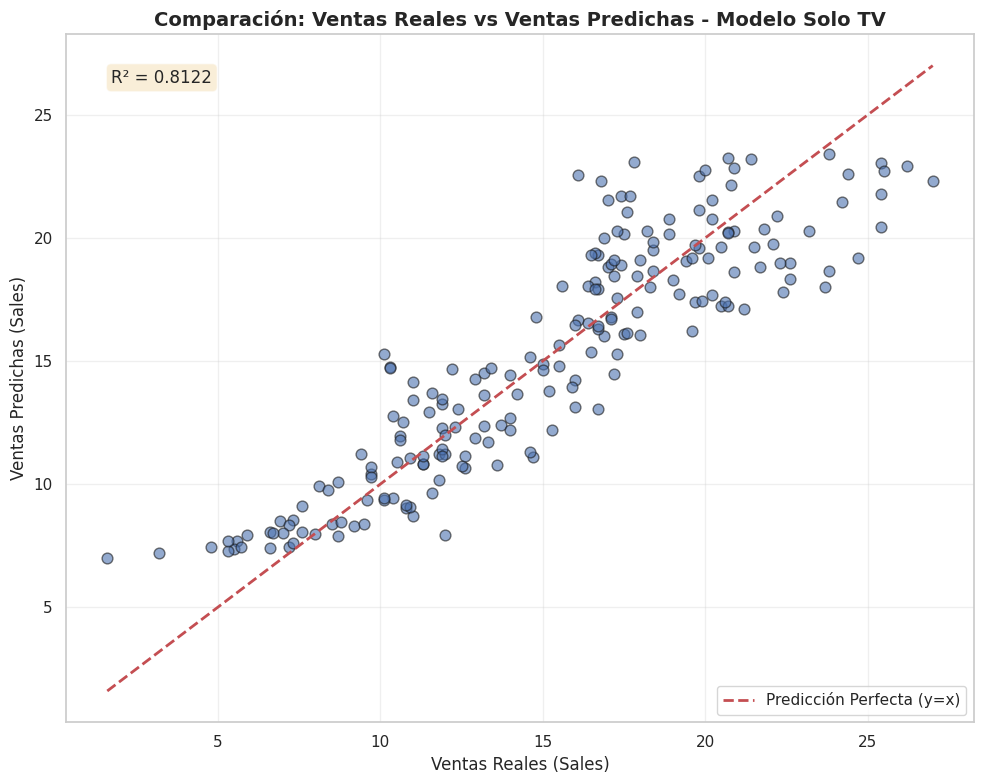

In [29]:
# Crear el gráfico de valores reales vs valores predichos del modelo solo TV
plt.figure(figsize=(10, 8))

# Graficar los puntos: ventas reales vs ventas predichas del modelo solo TV
plt.scatter(y_tv_solo, y_pred_tv_solo, alpha=0.6, edgecolors='k', s=60)

# Añadir una línea diagonal perfecta (y = x)
min_val = min(y_tv_solo.min(), y_pred_tv_solo.min())
max_val = max(y_tv_solo.max(), y_pred_tv_solo.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta (y=x)')

# Etiquetas y título
plt.xlabel('Ventas Reales (Sales)', fontsize=12)
plt.ylabel('Ventas Predichas (Sales)', fontsize=12)
plt.title('Comparación: Ventas Reales vs Ventas Predichas - Modelo Solo TV', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir información del R² en el gráfico
plt.text(0.05, 0.95, f'R² = {r2_tv_solo:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**¿Qué observas? ¿Qué información puedes obtener de esta gráfica?**

Mayor Dispersión:

Los puntos están más alejados de la línea diagonal comparado con modelos anteriores.

La nube de puntos es más dispersa y menos compacta.

Esto refleja visualmente el R² más bajo (0.8122)

Patrones Visibles:

Hay una mayor concentración de puntos en la zona central que desviados.

En ventas bajas (5-10), hay mayor variabilidad en las predicciones.

En ventas altas (20-26), la dispersión es aún más notable.

Muchos puntos están significativamente alejados de la línea roja

Sesgo Sistemático:

Para ventas bajas, el modelo tiende a sobrestimar ligeramente.

Para ventas muy altas, hay subestimaciones notables.

Esto indica que el modelo pierde capacidad predictiva en los extremos.

Comparación con Modelo Mejorado:

El modelo mejorado tenía puntos muy pegados a la diagonal.

Este modelo solo TV tiene una dispersión claramente mayor.

La diferencia visual es más puntos fuera de la banda de predicción.

**Conclusión:**

El gráfico demuestra visualmente que el modelo solo TV es notablemente inferior al modelo mejorado. La mayor dispersión de puntos confirma el R² de 0.8122 y el RMSE de 2.28. El modelo falla en capturar adecuadamente la relación completa entre inversión publicitaria y ventas, principalmente porque falta el efecto positivo de Radio en las predicciones.

# **Parte 6.7: Verificar el impacto de los atributos (Modelo Solo TV con Statsmodels)**

In [30]:
# Importar statsmodels para análisis estadístico detallado del modelo solo TV
import statsmodels.api as sm

# Definir las variables independientes solo TV y agregar una constante para el intercepto
X_tv_solo_constante = sm.add_constant(X_tv_solo)

# Definir la variable dependiente (y)
y_modelo_tv_solo = y_tv_solo

# Crear y ajustar el modelo de regresión lineal simple con statsmodels
modelo_sm_tv_solo = sm.OLS(y_modelo_tv_solo, X_tv_solo_constante)

# Ajustar el modelo a los datos
resultados_tv_solo = modelo_sm_tv_solo.fit()

# Mostrar el resumen completo del modelo solo TV con estadísticas detalladas
print(resultados_tv_solo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           7.93e-74
Time:                        02:42:09   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9748      0.323     21.624      0.0

**Observa los valores P>|t| en la tabla de salida:**

La tabla muestra los p-values para el modelo solo TV:

const (Intercepto): 0.000

TV: 0.000

**¿Qué variables tienen p-value menores a 0.05?**

TV (p-value = 0.000) Significativa

TV es estadísticamente significativa. Sin embargo, es la única variable en este modelo, por lo que solo hay un predictor disponible.

##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?

**El Modelo Mejorado (TV + Radio) es el mejor modelo.**

Máxima Capacidad Predictiva con Simplicidad: Explica el 90.26% de la variabilidad en ventas con solo 2 variables, igual que el modelo original con 3 variables.

Eliminación de Ruido: Removió Newspaper (p-value = 0.951), que no aportaba valor predictivo.

**Eficiencia:** Más simple y fácil de interpretar que el modelo original, sin pérdida de precisión.

Errores Mínimos: RMSE de 1.65 unidades, significativamente mejor que el modelo solo TV (2.28).

Todas las Variables son Significativas: TV y Radio tienen p-values = 0.000, confirmando su impacto real.

Cumplimiento de Supuestos: Normalidad de residuos, homocedasticidad y ausencia de multicolinealidad.

**¿Cuál fue el atributo que más influencia tiene en las ventas?**

**Radio es el atributo que más influencia tiene en las ventas.**

Coeficientes del Modelo Mejorado:

Radio: β = 0.1072

TV: β = 0.0544

Por cada unidad de inversión en Radio, las ventas aumentan 0.1072 unidades.

Por cada unidad de inversión en TV, las ventas aumentan 0.0544 unidades.

Radio tiene un coeficiente aproximadamente el doble que TV (0.1072 vs 0.0544).

Ambas variables tienen p-value = 0.000, confirmando su impacto significativo.

Radio es estadísticamente significativa e impacta más fuertemente en las ventas por unidad de inversión.

Radio mostró una correlación fuerte con Sales (r ≈ 0.78) en el análisis exploratorio

TV también tiene relación fuerte, pero el coeficiente de regresión de Radio es superior.

**Invertir en Radio genera mayor retorno por unidad monetaria que invertir en TV.**

**Sin embargo, ambas variables son esenciales para maximizar las ventas (R² de 90.26%)**

**La estrategia óptima es una combinación balanceada de inversión en TV y Radio, dando prioridad a Radio para maximizar el impacto.**